In [8]:
%load_ext autoreload
%autoreload 2

import pipeline
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import count
import time
import pickle
import shutil
import sys
import itertools
from collections import defaultdict
import geopandas as gpd
from tqdm.auto import tqdm
from libpysal.weights import Queen
import esda
import glob, os, re
from scipy.stats import ks_2samp
import math
from scipy.stats import wasserstein_distance
from haversine import haversine_vector

import plotly.io as pio
pio.renderers.default = "notebook"

seed = 21
interval = 6
agg = True

if agg:
    if interval == 6:
        fpath_pos = Path('data/agg/DEP_NET_UNDIRECT_GEOTAX11_14460_20190101_20191231_Tc6_Ts1.csv.gz')
        fpath_neg = Path('data/agg/DEP_NET_UNDIRECT_NEG_GEOTAX11_14460_20190101_20191231_Tc6_Ts1.csv.gz')
        save_dir = Path(f'data/agg/tests/seed{seed}')
    elif interval == 24:
        fpath = Path('data/agg/geotax_complete_24h.pkl')
        save_dir = Path(f'data/agg/tests/seed{seed}')
    else:
        print("Invalid time range (must be 24 or 6)")
else:
    if interval == 6:
        fpath = Path('data/poi_level/6h/thresholded_networks/0_network.txt')
        save_dir = Path(f'data/poi_level/6h/tests/seed{seed}')
        data = Path('data/poi_level/depnet_undirected.gz')
    elif interval == 24:
        fpath = Path('data/poi_level/24h/0_network_24h.txt')
        save_dir = Path(f'data/poi_level/24h/tests/seed{seed}')
        data = Path('data/poi_level/24h/depnet_undirected_24h.gz')
    else:
        print("Invalid time range (must be 24 or 6)")

save_dir.mkdir(parents=True, exist_ok=True)

print(f"Interval: {interval} hrs | agg: {agg} | Seed: {seed}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Interval: 6 hrs | agg: True | Seed: 21


In [9]:
_dtypes = {
    'NODE_A': 'category', 'NODE_B': 'category',
    'N_COVISITS': 'float32', 'DIST_KM_MIN': 'float32',
    'DIST_KM_MEAN': 'float32', 'DIST_KM_MEDIAN': 'float32',
    'DIST_KM_CENTROID': 'float32', 'N_UIDS_A': 'float32',
    'N_POIS_A': 'float32', 'N_VISITS_A': 'float32',
    'N_UIDS_B': 'float32', 'N_POIS_B': 'float32',
    'N_VISITS_B': 'float32', 'DEP': 'float32', 'BIN': 'int'
}
def fast_read_csv(fpath, _dtypes):
    headers = pd.read_csv(fpath, nrows=0).columns
    _dtypes = {col: dt for col, dt in _dtypes.items() if col in headers}
    return pd.read_csv(fpath, dtype=_dtypes)

df_pos = fast_read_csv(fpath_pos, _dtypes)
df_neg = fast_read_csv(fpath_neg, _dtypes)

### Agg Network Examination

In [7]:
def exam(df):
    print(df.info())
    print(df.head())

exam(df_pos)
exam(df_neg)

<class 'pandas.DataFrame'>
RangeIndex: 4620138 entries, 0 to 4620137
Data columns (total 16 columns):
 #   Column            Dtype   
---  ------            -----   
 0   NODE_A            category
 1   NODE_B            category
 2   N_COVISITS        float32 
 3   N_UIDS_A          float32 
 4   N_POIS_A          float32 
 5   N_VISITS_A        float32 
 6   N_UIDS_B          float32 
 7   N_POIS_B          float32 
 8   N_VISITS_B        float32 
 9   DEP               float32 
 10  DIST_KM_CENTROID  float32 
 11  BIN               int64   
 12  SPLIT             str     
 13  DIST_KM_MIN       float32 
 14  DIST_KM_MEDIAN    float32 
 15  DIST_KM_MEAN      float32 
dtypes: category(2), float32(12), int64(1), str(1)
memory usage: 300.9 MB
None
                              NODE_A                            NODE_B  \
0                25021404302_Grocery        25025000803_Transportation   
1           25009211300_Coffee / Tea              25009266300_Industry   
2               25017

In [14]:
# check that train_pos contains all nodes
def node_counter(df, y=False):
    train = df[df['SPLIT'] == 'TRAIN']
    test = df[df['SPLIT'] == 'TEST']
    n_train = len(np.unique(train[['NODE_A', 'NODE_B']].dropna()))
    n_test = len(np.unique(test[['NODE_A', 'NODE_B']].dropna()))
    return (train, n_train, n_test) if y else (n_train, n_test)

train_pos, n_train_pos, n_test_pos = node_counter(df_pos, y=True)
n_train_neg, n_test_neg = node_counter(df_neg)

is_complete = bool(n_train_pos == n_test_pos == n_train_neg == n_test_neg)
print(f'Complete: {is_complete}')
print(
    f'train_pos: {n_train_pos}\ntrain_neg: {n_train_neg}\ntest_pos: {n_test_pos}\ntest_neg: {n_test_neg}'
)

def node_set(df, split):
    d = df[df['SPLIT'] == split][['NODE_A', 'NODE_B']].dropna()
    return set(pd.unique(d.values.ravel()))

train_pos_nodes = node_set(df_pos, 'TRAIN')
missing = {
    'test_pos':  node_set(df_pos, 'TEST')  - train_pos_nodes,
    'train_neg': node_set(df_neg, 'TRAIN') - train_pos_nodes,
    'test_neg':  node_set(df_neg, 'TEST')  - train_pos_nodes,
}
print(f'Complete: {all(not v for v in missing.values())}')
for k, v in missing.items():
    print(f'{k}: {len(v)} nodes absent from train_pos'
          + (f' (e.g. {sorted(v)[:3]})' if v else ''))


# check connectivity
G = nx.from_pandas_edgelist(train_pos, 'NODE_A', 'NODE_B')
print(f'Connected: {nx.is_connected(G)}')

Complete: False
train_pos: 15134
train_neg: 15134
test_pos: 15010
test_neg: 15134
Complete: True
test_pos: 0 nodes absent from train_pos
train_neg: 0 nodes absent from train_pos
test_neg: 0 nodes absent from train_pos
Connected: True


,DIST_KM_CENTROID,DIST_KM_MEAN,DIST_KM_MEDIAN,DIST_KM_MIN
count,4.620138e+06,4.620138e+06,4.620138e+06,4.620138e+06
mean,1.565917e+01,1.570418e+01,1.569226e+01,1.422386e+01
std,1.488853e+01,1.486926e+01,1.487438e+01,1.450356e+01
min,7.392925e-04,7.392925e-04,7.392925e-04,0.000000e+00
25%,5.020205e+00,5.076266e+00,5.062887e+00,3.949808e+00
50%,1.099780e+01,1.103735e+01,1.101814e+01,9.546694e+00
75%,2.157343e+01,2.160009e+01,2.158782e+01,1.973411e+01
max,1.860903e+02,1.860981e+02,1.861122e+02,1.853705e+02


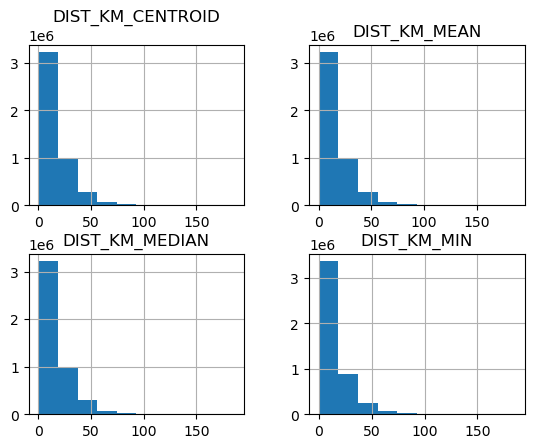

In [17]:
# checking distributions to see if i need to log-compress

df_pos_dist = df_pos[['DIST_KM_CENTROID', 'DIST_KM_MEAN', 'DIST_KM_MEDIAN', 'DIST_KM_MIN']]
df_pos_dist.hist()
df_pos_dist.describe()

,DIST_KM_CENTROID,DIST_KM_MEAN,DIST_KM_MEDIAN,DIST_KM_MIN
count,4.620138e+06,4.620138e+06,4.620138e+06,4.620138e+06
mean,1.584902e+01,1.586847e+01,1.586204e+01,1.509854e+01
std,1.574330e+01,1.573731e+01,1.573743e+01,1.544711e+01
min,1.111949e-04,1.111949e-04,1.111949e-04,0.000000e+00
25%,5.023088e+00,5.043837e+00,5.040783e+00,4.535892e+00
50%,1.100176e+01,1.101726e+01,1.101003e+01,1.030945e+01
75%,2.158351e+01,2.159782e+01,2.158552e+01,2.056084e+01
max,1.941085e+02,1.941272e+02,1.936480e+02,1.896402e+02


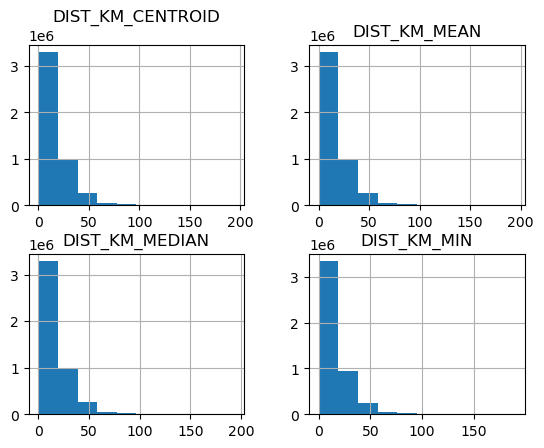

In [18]:
df_neg_dist = df_neg[['DIST_KM_CENTROID', 'DIST_KM_MEAN', 'DIST_KM_MEDIAN', 'DIST_KM_MIN']]
df_neg_dist.hist()
df_neg_dist.describe()

N_COVISITS
1.0       2951168
2.0        833313
3.0        382528
4.0        221720
5.0        145365
           ...   
1619.0          1
1256.0          1
1175.0          1
1414.0          1
1265.0          1
Name: count, Length: 2009, dtype: int64
0 nulls

DEP descriptive stats
count    5.229044e+06
mean     3.363632e-07
std      6.896293e-06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.403000e-03
Name: DEP, dtype: float64
0 nulls


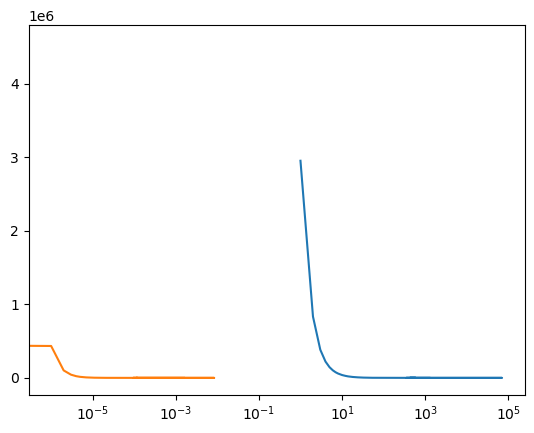

In [ ]:
#plt.semilogx(df['N_COVISITS'].value_counts())
print(df['N_COVISITS'].value_counts())
print(f'{df["N_COVISITS"].isna().sum()} nulls')

print('\nDEP descriptive stats')
plt.semilogx(df['DEP'].value_counts())
print(df['DEP'].describe())
print(f'{df["DEP"].isna().sum()} nulls')

In [2]:
G, train_non_edges, test_pos_edges, test_non_edges = pipeline.prepare_data(fpath, test_frac=0.25, controlled=False, meta=True)

Nodes: 15831
Edges: 5288458


sampling non-edges:   0%|          | 0/1322114 [00:00<?, ?edge/s]

sampling non-edges:   0%|          | 0/3966344 [00:00<?, ?edge/s]

Wrote training graph: 15831 nodes, 3966344 edges


In [3]:
# checking unmatched distribution of weak vs strong class

trainfile = 'data/train.txt'
G_train = nx.read_edgelist(
    trainfile, data=[('weight', float)], delimiter='\t')
train_pos_edges = [tuple(sorted(e)) for e in G_train.edges()]

def _dep(edges, keep):
    return np.array([G[u][v]['DEP'] for u, v in edges],
                    dtype=np.float64)[keep]

keep_train_pos = list(range(len(train_pos_edges)))
keep_test_pos = list(range(len(test_pos_edges)))

# save original index order to match back to G
edges_train = np.array(train_pos_edges, dtype=object)
edges_test = np.array(test_pos_edges, dtype=object)
edges_all = np.concatenate((edges_train, edges_test))

# deps

dep_train = _dep(train_pos_edges, keep_train_pos)
dep_test = _dep(test_pos_edges, keep_test_pos)
dep_all = np.concatenate((dep_train, dep_test))

dep_train, edges_train = dep_train[dep_train > 0], edges_train[dep_train > 0]
dep_test, edges_test = dep_test[dep_test > 0], edges_test[dep_test > 0]
dep_all, edges_all = dep_all[dep_all > 0], edges_all[dep_all > 0]

# actual sorted edges plus indices of sorted edges for later lookup
train_order, test_order, all_order = np.argsort(dep_train), np.argsort(dep_test), np.argsort(dep_all)
dep_train, edges_train = dep_train[train_order], edges_train[train_order]
dep_test, edges_test = dep_test[test_order], edges_test[test_order]
dep_all, edges_all = dep_all[all_order], edges_all[all_order]

# fit on train only to match pipeline behavior
thr = np.quantile(dep_train, 0.5)

train_mask = dep_train > thr
dep_train_strong, edges_train_strong = dep_train[train_mask], edges_train[train_mask]
dep_train_weak, edges_train_weak = dep_train[~train_mask], edges_train[~train_mask]

test_mask = dep_test > thr
dep_test_strong, edges_test_strong = dep_test[test_mask], edges_test[test_mask]
dep_test_weak, edges_test_weak = dep_test[~test_mask], edges_test[~test_mask]

all_mask = dep_all > thr
dep_all_strong, edges_all_strong = dep_all[all_mask], edges_all[all_mask]
dep_all_weak, edges_all_weak = dep_all[~all_mask], edges_all[~all_mask]

# distances

def _dist(edges):
    return np.array([G[u][v]['DIST_KM_MEAN'] for u, v in edges], dtype=np.float32)

dist_train_strong = _dist(edges_train_strong)
dist_train_weak = _dist(edges_train_weak)
dist_train = _dist(edges_train)
dist_test_strong = _dist(edges_test_strong)
dist_test_weak = _dist(edges_test_weak)
dist_test = _dist(edges_test)
dist_all_strong = _dist(edges_all_strong)
dist_all_weak = _dist(edges_all_weak)
dist_all = _dist(edges_all)


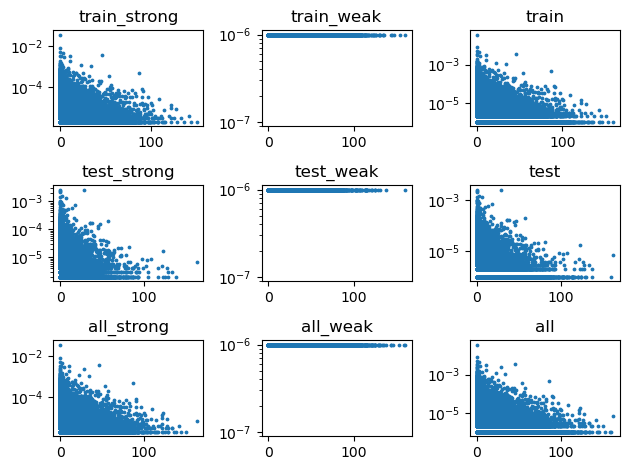

In [16]:
# plot dep against distance

fig, ax = plt.subplots(3, 3)

order = [
    (dist_train_strong, dep_train_strong),
    (dist_train_weak, dep_train_weak), 
    (dist_train, dep_train),
    (dist_test_strong, dep_test_strong), 
    (dist_test_weak, dep_test_weak), 
    (dist_test, dep_test),
    (dist_all_strong, dep_all_strong), 
    (dist_all_weak, dep_all_weak), 
    (dist_all, dep_all)
]
titles = ['train_strong', 'train_weak', 'train',
         'test_strong', 'test_weak', 'test',
         'all_strong', 'all_weak', 'all']

cur_row_idx = 0
cur_col_idx = 0
for i, (dist_class, dep_class) in enumerate(order):
    ax[cur_row_idx, cur_col_idx].scatter(dist_class, dep_class, s=3)
    ax[cur_row_idx, cur_col_idx].set_title(titles[i])
    # ax[cur_row_idx, cur_col_idx].set_xscale('log')
    ax[cur_row_idx, cur_col_idx].set_yscale('log')
    if i in [2, 5]:
        cur_col_idx = 0
        cur_row_idx += 1
    else:
        cur_col_idx += 1

plt.tight_layout()
plt.savefig('figures/agg/temp/strength_dep_dist_logy.png')

In [4]:
# isolate distance-controlling to see its behavior

def _dist_matched_idx(dep, dist, thr):
    # same log bins as the link version, then keep min(#strong, #weak)
    strong = dep > thr
    if dist.max() > 0.01:
        edges_b = np.concatenate(
            ([0], np.geomspace(0.01, dist.max(), 50)))
    else:
        edges_b = np.linspace(0, dist.max() + 1e-5, 50)
    # indexes the bin that each edge falls into
    b = np.digitize(dist, edges_b)
    keep = []
    for bin_id in np.unique(b):
        # strong and weak within bin (returns indices)
        in_bin = np.where(b == bin_id)[0]
        s = in_bin[strong[in_bin]]
        w = in_bin[~strong[in_bin]]
        k = min(len(s), len(w))
        if k == 0:
            continue
        # select k random samples from within-bin subsets w/o replacement
        # (smaller one technically just gets copied but its fast enough
        # that the redundancy doesn't matter)
        keep.extend(np.random.choice(s, k, replace=False))
        keep.extend(np.random.choice(w, k, replace=False))
    return np.sort(np.array(keep, dtype=int))

idx_tr = _dist_matched_idx(dep_train, dist_train, thr)
idx_te = _dist_matched_idx(dep_test, dist_test, thr)

# filter dep/edges/dist down to the matched subset
dep_train_matched, edges_train_matched, dist_train_matched = (
    dep_train[idx_tr], edges_train[idx_tr], dist_train[idx_tr])
dep_test_matched, edges_test_matched, dist_test_matched = (
    dep_test[idx_te], edges_test[idx_te], dist_test[idx_te])

y_str_train_matched = (dep_train_matched > thr).astype(int)
y_str_test_matched = (dep_test_matched > thr).astype(int)

print(f"Distance-matched strength set: "
      f"train {len(idx_tr)}/{len(dep_train)}, "
      f"test {len(idx_te)}/{len(dep_test)} edges kept")
if len(np.unique(y_str_test_matched)) < 2 or len(np.unique(y_str_train_matched)) < 2:
    print("Warning: a strength class vanished after distance "
          "matching — cannot score.")

Distance-matched strength set: train 314420/523964, test 104900/174356 edges kept


In [9]:
# confirm the floor pileup in nonzero DEP

floor_val = np.float32(1e-6)
n_at_floor = (dep_all == floor_val).sum()
print(f"Nonzero DEP edges: {len(dep_all)}")
print(f"Edges exactly at floor ({floor_val}): {n_at_floor} ({n_at_floor / len(dep_all):.2%})")

# most common nonzero DEP values
vals, counts = np.unique(dep_all, return_counts=True)
order = np.argsort(counts)[::-1]
print("\nTop 10 most common nonzero DEP values:")
for v, c in zip(vals[order][:10], counts[order][:10]):
    print(f"  {v:.6e} : {c} edges ({c / len(dep_all):.2%})")

# quantile sweep to see where the distribution escapes the floor pileup
print("\nQuantile sweep:")
for q in [0.5, 0.7, 0.8, 0.87, 0.9, 0.95, 0.99]:
    print(f"  q={q:.2f} -> {np.quantile(dep_all, q):.6e}")

Nonzero DEP edges: 698320
Edges exactly at floor (9.999999974752427e-07): 451068 (64.59%)

Top 10 most common nonzero DEP values:
  1.000000e-06 : 451068 edges (64.59%)
  2.000000e-06 : 107247 edges (15.36%)
  3.000000e-06 : 46714 edges (6.69%)
  4.000000e-06 : 25130 edges (3.60%)
  5.000000e-06 : 15469 edges (2.22%)
  6.000000e-06 : 10132 edges (1.45%)
  7.000000e-06 : 7260 edges (1.04%)
  8.000000e-06 : 5232 edges (0.75%)
  9.000000e-06 : 4122 edges (0.59%)
  1.000000e-05 : 3267 edges (0.47%)

Quantile sweep:
  q=0.50 -> 1.000000e-06
  q=0.70 -> 2.000000e-06
  q=0.80 -> 3.000000e-06
  q=0.87 -> 4.000000e-06
  q=0.90 -> 4.000000e-06
  q=0.95 -> 8.000000e-06
  q=0.99 -> 2.500000e-05


In [ ]:
# bugfix pipeline

G = pipeline.load(fpath)
dep_edges = sum(1 for _, _, d in G.edges(data=True) if d.get('DEP', 0) != 0)
total_edges = G.number_of_edges()

print(f"{dep_edges}/{total_edges}")

### Thresholded Network Build (POI-level)

In [ ]:
# --- dependency distribution ---

# reading in + dealing with missing values
df = pd.read_csv(data)
df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
df = df.dropna(subset=['DEP'])

# sampling for performance
plot_data = df['DEP'].sample(100000)
print(plot_data.describe())

sns.displot(plot_data, bins=30, kde=True, stat='probability', log_scale=True)
plt.margins(x=0)

# --- num removed vs binned values ---

dep_nonzero = df.loc[df['DEP'] > 0, 'DEP'].sort_values().values
total_edges = len(df)
zero_edges = total_edges - len(dep_nonzero)

print(f"Total edges: {total_edges}")
print(f"Zero-DEP edges: {zero_edges}")
print(f"Nonzero DEP range: [{dep_nonzero.min():.2e}, {dep_nonzero.max():.2e}]")

# log-spaced bins across the nonzero DEP range
bins = np.logspace(np.log10(dep_nonzero.min()), np.log10(dep_nonzero.max()), 200)

# for each threshold, edges retained = nonzero edges with DEP >= threshold
edges_retained = len(dep_nonzero) - np.searchsorted(dep_nonzero, bins, side='left')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bins, edges_retained)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('DEP threshold')
ax.set_ylabel('Number of edges retained')
ax.set_title('Edges retained vs DEP threshold')

ax.axhline(y=1_000_000, color='r', linestyle='--', label='1M edges')
ax.axhline(y=10_000, color='orange', linestyle='--', label='10k edges')
ax.legend()
plt.show()

# find approximate thresholds
vals = []
for target, label in [(1_000_000, 'DEP_low (~1M)'), (10_000, 'DEP_high (~10k)')]:
    idx = np.argmin(np.abs(edges_retained - target))
    vals.append(bins[idx])
    print(f"{label}: DEP â‰ˆ {bins[idx]:.6e}, edges retained = {edges_retained[idx]}")

DEP_low = vals[0]
DEP_high = vals[1]

In [ ]:
all = 0

# reloading df if needed
if 'df' not in globals():
    df = pd.read_csv(data)
    df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
    df = df.dropna(subset=['DEP'])

if all:
    # filtering
    DEP_range = df[df['DEP'].between(DEP_low, DEP_high)]
    # calculating thresholds with bounded range
    quantiles = np.quantile(DEP_range['DEP'], [0.25, 0.5, 0.75])
    thresholds = np.concatenate([[DEP_low], quantiles, [DEP_high]])

    # creating networks with original uncapped df
    for i, threshold in zip(count(0, 0.25), thresholds):
        # filter
        thresholded_df = df[df['DEP'] >= threshold]
        
        # save df directly
        filepath = f'data/undir_trials/thresholded_networks/{i}_network.txt'
        thresholded_df.to_csv(filepath, sep=' ', index=False, header=False)
        
        print(f"Saved {filepath} with {len(thresholded_df)} edges")
else:
    thresholded_df = df[df['DEP'] >= DEP_low]
    filepath = f'data/undir_trials/24h/network.txt'
    thresholded_df.to_csv(filepath, sep=' ', index=False, header=False)
    print(f"Saved {filepath} with {len(thresholded_df)} edges")